# 02 — Feature Engineering (v2 — Enhanced for Deep Learning)
### 2023/24 Kenya Housing Survey · MSc Dissertation
**Strathmore University · Data Science & Analytics**

## What changed from v1

| Bug | v1 (wrong) | v2 (fixed) |
|-----|-----------|------------|
| `no_land_ownership` = 0% | `safe_flag('i00', {2.0})` — code 2 never exists | `safe_flag('i00', {0.0})` — i00=0 means No |
| Floor 85% durable | Earth/sand, Dung in DURABLE set | Only tiles, concrete, carpet durable |
| Solid fuel = 0.6% | Codes {2–6} are electricity variants | Charcoal (9) = 54%, firewood (7) = 25% |
| Flood = 6.5% | Only severe (code 1) | Severe + mild (codes 1+2), weighted |
| 0% high vulnerability | Above bugs suppress D2 + D4 | Fixed scores with percentile thresholds |

## New additions for deep learning
- **Three model-ready datasets**: `X_tree`, `X_nn`, `X_interpretable`
- **Rich raw features**: one-hot materials, ordinal education, distance vars
- **Interaction features**: 8 cross-dimension interactions
- **Spatial context features**: county-level aggregates as household features
- **Migration features** from individual file
- **Three target formulations**: continuous, binary, 3-class
- **Standardised + robust-scaled** versions for NN stability

**Output files:**
- `master_hfvs_v2.parquet` — full dataset, all features
- `X_tree.parquet` — tree models (XGBoost, LightGBM, RF)
- `X_nn.parquet` — neural networks (MLP, TabNet, autoencoders)
- `X_interpretable.parquet` — logistic regression, GLM

---
## 1. Environment Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content')
!git clone https://github.com/VAL-Jerono/KHS_housing_dissertation.git 2>/dev/null || \
    (cd KHS_housing_dissertation && git pull)
os.chdir('KHS_housing_dissertation')
sys.path.insert(0, 'src')

Mounted at /content/drive


In [2]:
!pip install -q polars pyarrow scikit-learn matplotlib seaborn scipy

In [3]:
import json, warnings
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
np.random.seed(42)

DRIVE  = Path("/content/drive/MyDrive/KHS_Dissertation")
PQ     = DRIVE / "data" / "parquet"
FIGS   = DRIVE / "outputs" / "figures"
TABLES = DRIVE / "outputs" / "tables"
for p in [FIGS, TABLES]: p.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F8F6', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.titlesize': 13,
    'axes.titleweight': '500', 'axes.labelsize': 11,
})
TEAL='#00695C'; PURPLE='#6A1B9A'; AMBER='#E65100'
RED='#B71C1C'; BLUE='#1565C0'; GRAY='#546E7A'

with open(PQ / 'household_variable_labels.json') as f: HH_VAR = json.load(f)
with open(PQ / 'household_value_labels.json')   as f: HH_VAL = json.load(f)
with open(PQ / 'dwelling_variable_labels.json')  as f: DW_VAR = json.load(f)
with open(PQ / 'dwelling_value_labels.json')     as f: DW_VAL = json.load(f)
with open(PQ / 'individual_variable_labels.json')as f: IND_VAR= json.load(f)

FILES = {
    'household':  'Household_Information_Data.parquet',
    'individual': 'Individual_Data.parquet',
    'dwelling':   'Dwelling_Units_Data.parquet',
    'county':     'County_Physical_Planning_Data.parquet',
}

def winsorise(s, lo=0.01, hi=0.99):
    s = pd.to_numeric(s, errors='coerce')
    return s.clip(s.quantile(lo), s.quantile(hi))

def safe_flag(col, insecure_codes, df=None):
    """Return 1.0 where value is in insecure_codes, 0.0 otherwise, NaN preserved."""
    s = pd.to_numeric(df[col], errors='coerce') if col in df.columns else pd.Series(np.nan, index=df.index)
    return s.isin(insecure_codes).astype(float).where(s.notna(), np.nan)

print("Environment ready.")

Environment ready.


---
## 2. Load Files & Build Master Spine

In [4]:
hh  = pl.read_parquet(PQ / FILES['household']).to_pandas()
dw  = pl.read_parquet(PQ / FILES['dwelling']).to_pandas()
ind = pl.read_parquet(PQ / FILES['individual']).to_pandas()
print(f"hh: {hh.shape}  |  dw: {dw.shape}  |  ind: {ind.shape}")

# ── Dwelling: keep primary unit per household ──────────────────────────
dw_primary = (
    dw.sort_values(['interview__key', 'd12'], ascending=[True, True])
      .groupby('interview__key', as_index=False).first()
)
dw_cols = ['interview__key','d03','d04','d05','d06','d07','d08','d08_1',
           'd09','d10','d11_1','d12','d14','d15','d16']
dw_cols = [c for c in dw_cols if c in dw_primary.columns]

# ── Individual: aggregate to household grain ──────────────────────────
ind['age_n']      = pd.to_numeric(ind['age_cur'], errors='coerce')
ind['edu_isced']  = pd.to_numeric(ind.get('ken_edu_isced11', pd.Series(np.nan)), errors='coerce')
ind['is_wap']     = pd.to_numeric(ind.get('wap_1', pd.Series(0)), errors='coerce').fillna(0)
ind['born_here']  = (ind['b09_3'] == -1).astype(float)  # -1 = living continuously = born here

ind_agg = (
    ind.groupby('interview__key', as_index=False).agg(
        ind_hh_size    = ('interview__key', 'count'),
        mean_age       = ('age_n', 'mean'),
        n_children     = ('age_n', lambda x: (x < 15).sum()),
        n_elderly      = ('age_n', lambda x: (x >= 65).sum()),
        n_working_age  = ('is_wap', 'sum'),
        max_edu_isced  = ('edu_isced', 'max'),
        mean_edu_isced = ('edu_isced', 'mean'),
        pct_born_here  = ('born_here', 'mean'),   # share of hh members born/always lived here
        n_female       = ('b04', lambda x: (pd.to_numeric(x, errors='coerce') == 2).sum()),
    )
)
ind_agg['dependency_ratio'] = (
    (ind_agg['n_children'] + ind_agg['n_elderly']) /
    ind_agg['n_working_age'].replace(0, np.nan)
).clip(0, 10)
ind_agg['wap_share']    = ind_agg['n_working_age'] / ind_agg['ind_hh_size']
ind_agg['female_share'] = ind_agg['n_female'] / ind_agg['ind_hh_size']

# ── Join to household spine ────────────────────────────────────────────
master = (
    hh
    .merge(dw_primary[dw_cols], on='interview__key', how='left', suffixes=('','_dw'))
    .merge(ind_agg,             on='interview__key', how='left')
)
master['hh_size'] = pd.to_numeric(master['a12'], errors='coerce').fillna(master['ind_hh_size'])
master['residence'] = master['a07_1'].map({1:'Rural', 2:'Urban'})
print(f"Master: {master.shape[0]:,} rows × {master.shape[1]} cols")

hh: (21347, 392)  |  dw: (25116, 25)  |  ind: (80889, 97)
Master: 21,347 rows × 420 cols


---
## 3. Confirmed Material Classification Maps
All codes verified from actual Stata value labels extracted in notebook 01.

In [5]:
# ── FLOOR (d14) ─── confirmed from labels ─────────────────────────────
# NON-durable: Earth/sand(1), Dung(2), Wood planks(3), Palm/bamboo(4)
# DURABLE: Parquet/polished wood(5), Vinyl(6), Ceramic tiles(7), Concrete/cement/terrazzo(8), Carpet(9)
FLOOR_DURABLE     = {5.0, 6.0, 7.0, 8.0, 9.0}
FLOOR_NON_DURABLE = {1.0, 2.0, 3.0, 4.0}

# Ordinal quality ranking (for regression-friendly encoding)
FLOOR_QUALITY = {1.0:0, 2.0:0, 3.0:1, 4.0:1, 5.0:2, 6.0:2, 7.0:3, 8.0:3, 9.0:3}

# ── WALL (d15) ─── confirmed from labels ──────────────────────────────
# NON-durable: No walls(1), Cane/palm(2), Grass/reeds(3), Mud/dung(4),
#              Bamboo+mud(5), Stone+mud(6), Uncovered adobe(7),
#              Plywood/cardboard(8), Reused wood(9), Wood planks(16)
# DURABLE: Iron sheets(10), Concrete/cement(11), Stone+lime/cement(12),
#          Bricks(13), Cement blocks(14), Covered adobe(15), Precast(17)
WALL_DURABLE     = {10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 17.0}
WALL_NON_DURABLE = {1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 16.0}

WALL_QUALITY = {
    1.0:0, 2.0:0, 3.0:0, 4.0:0, 5.0:1, 6.0:1, 7.0:1,
    8.0:0, 9.0:0, 16.0:1, 10.0:2, 15.0:2, 11.0:3, 12.0:3, 13.0:3, 14.0:3, 17.0:3
}

# ── ROOF (d16) ─── confirmed from labels ──────────────────────────────
# NON-durable: Grass/thatch(1), Dung/mud(2), Tin cans(4), Canvas/cardboard(8)
# DURABLE: Iron sheets(3), Asbestos(5), Concrete(6), Tiles(7)
# NOTE: Asbestos is structurally durable but carries health risk — flagged separately
ROOF_DURABLE     = {3.0, 5.0, 6.0, 7.0}
ROOF_NON_DURABLE = {1.0, 2.0, 4.0, 8.0}
ROOF_QUALITY     = {1.0:0, 2.0:0, 4.0:0, 8.0:0, 5.0:2, 3.0:3, 6.0:3, 7.0:3}

# ── COOKING FUEL (c11) ─── confirmed: top values are 9=charcoal, 7=firewood
# Improved: 1-6 (electricity variants), 10 (LPG/gas), 12 (bioethanol)
# Unimproved: 7(firewood), 8(crop residues), 9(charcoal), 11(kerosene), 13(coal/lignite), 14(dung)
SOLID_FUEL_CODES = {7.0, 8.0, 9.0, 11.0, 13.0, 14.0}

# ── WATER (c01_1) ─── confirmed labels
# Improved: 1(public water co), 2(private water co), 3(owned borehole), 4(community borehole)
# Unimproved: 5(protected well), 6(unprotected well), 7(protected spring),
#             8(unprotected spring), 9(rainwater), 10(surface water), 11(tanker)
UNIMPROVED_WATER  = {6.0, 8.0, 10.0, 11.0, 12.0}  # strictly unimproved by JMP standard
LIMITED_WATER     = {4.0, 5.0, 7.0, 9.0}           # limited/basic

# ── TOILET (c04) ─── confirmed labels
# Improved: 1(flush sewer), 2(flush septic), 3(flush pit), 6(VIP pit latrine)
# Unimproved: 7(basic pit), 8(hanging toilet), 9(bucket), 10(no facility)
# Shared = further downgrade: c05=1 means shared
UNIMPROVED_TOILET = {7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0}
LIMITED_TOILET    = {3.0, 4.0, 5.0, 6.0}

print("Material classification maps confirmed.")
print("  Floor durable codes:", FLOOR_DURABLE)
print("  Wall durable codes: ", WALL_DURABLE)
print("  Roof durable codes: ", ROOF_DURABLE)
print("  Solid fuel codes:   ", SOLID_FUEL_CODES)

Material classification maps confirmed.
  Floor durable codes: {5.0, 6.0, 7.0, 8.0, 9.0}
  Wall durable codes:  {17.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0}
  Roof durable codes:  {3.0, 5.0, 6.0, 7.0}
  Solid fuel codes:    {7.0, 8.0, 9.0, 11.0, 13.0, 14.0}


---
## 4. Dimension 1 — Financial Stress (v2)
Added: savings-to-income ratio, investment flag, absolute expenditure quintile.

In [6]:
master['expenditure']   = winsorise(master['c14_1'])
master['savings']       = winsorise(master['c14_2'])
master['investments']   = winsorise(master['c14_3'])
master['monthly_rent']  = winsorise(master['k05'])

# ── Rent burden ────────────────────────────────────────────────────────
mask_r = master['monthly_rent'].notna() & master['expenditure'].notna() & \
         (master['monthly_rent'] > 0) & (master['expenditure'] > 0)
master.loc[mask_r, 'rent_burden'] = (
    master.loc[mask_r, 'monthly_rent'] / master.loc[mask_r, 'expenditure']
).clip(0, 1)

# Owners: l15 = estimated rental value they could charge
if 'l15' in master.columns:
    l15 = winsorise(master['l15'])
    mask_o = master['rent_burden'].isna() & l15.notna() & master['expenditure'].notna() & \
             (l15 > 0) & (master['expenditure'] > 0)
    master.loc[mask_o, 'rent_burden'] = (
        l15[mask_o] / master.loc[mask_o, 'expenditure']
    ).clip(0, 1)

# Fill remaining with county × residence median
master['rent_burden'] = master['rent_burden'].fillna(
    master.groupby(['a01','a07_1'])['rent_burden'].transform('median')
).fillna(master['rent_burden'].median())

# ── Savings-to-income ratio ────────────────────────────────────────────
master['savings_rate'] = (
    master['savings'] / master['expenditure'].replace(0, np.nan)
).clip(0, 1).fillna(0)

# ── Expenditure quintile (socioeconomic proxy) ─────────────────────────
master['expenditure_quintile'] = pd.qcut(
    master['expenditure'].rank(method='first'), 5, labels=[1,2,3,4,5]
).astype(float)

# ── Binary flags ──────────────────────────────────────────────────────
master['rent_stressed']    = (master['rent_burden'] > 0.30).astype(float)
master['severely_stressed']= (master['rent_burden'] > 0.50).astype(float)
master['no_savings']       = (master['savings'].fillna(0) == 0).astype(float)
master['has_investments']  = (master['investments'].fillna(0) > 0).astype(float)
master['low_income_flag']  = pd.to_numeric(master.get('d20__8', 0), errors='coerce').fillna(0)
master['no_loan_access']   = pd.to_numeric(master.get('d20__4', 0), errors='coerce').fillna(0)
master['high_rent_cost']   = pd.to_numeric(master.get('d20__1', 0), errors='coerce').fillna(0)
master['high_interest']    = pd.to_numeric(master.get('d20__6', 0), errors='coerce').fillna(0)

# ── D1 score ──────────────────────────────────────────────────────────
rb_norm = MinMaxScaler().fit_transform(master[['rent_burden']]).flatten()
sr_inv  = 1 - MinMaxScaler().fit_transform(master[['savings_rate']]).flatten()  # low savings = high stress

master['d1_financial_stress'] = (
    0.45 * rb_norm          +
    0.20 * sr_inv           +
    0.15 * master['no_savings']       +
    0.10 * master['low_income_flag']  +
    0.10 * master['no_loan_access']
).clip(0, 1)

print(f"D1 Financial Stress: mean={master['d1_financial_stress'].mean():.3f}  "
      f"std={master['d1_financial_stress'].std():.3f}")
print(f"  Rent-stressed (>30%):    {master['rent_stressed'].mean()*100:.1f}%")
print(f"  Severely stressed (>50%): {master['severely_stressed'].mean()*100:.1f}%")
print(f"  No savings:               {master['no_savings'].mean()*100:.1f}%")

D1 Financial Stress: mean=0.470  std=0.172
  Rent-stressed (>30%):    54.8%
  Severely stressed (>50%): 30.6%
  No savings:               57.4%


---
## 5. Dimension 2 — Tenure Insecurity (v2 — BUG FIXED)
**Fix:** `i00=0` means does NOT own land (not code 2). Previously returning 0% insecure.

In [7]:
# ── Confirm i00 coding ─────────────────────────────────────────────────
print("i00 value counts:", master['i00'].value_counts().to_dict())
print("i00 labels:", HH_VAL.get('I00', HH_VAL.get('i00', {})))
# Expected: {0: 'No', 1: 'Yes'} → no ownership = code 0

# ── BUG FIX: i00=0 means does NOT own land ─────────────────────────────
master['no_land_ownership'] = safe_flag('i00', {0.0}, df=master)  # FIXED from {2.0}

# ── Other tenure flags (coding confirmed from v1 labels output) ────────
master['no_written_lease']  = safe_flag('k02', {2.0}, df=master)  # 2=No
master['rent_dispute_hist'] = safe_flag('k29', {1.0}, df=master)  # 1=Yes
master['demo_neighbourhood']= safe_flag('k34', {1.0}, df=master)  # 1=Yes
master['eviction_threat']   = safe_flag('k35', {1.0}, df=master)  # 1=Yes
master['demo_threat']       = safe_flag('l26', {1.0}, df=master)  # 1=Yes
master['no_dev_approval']   = safe_flag('l29', {2.0}, df=master)  # 2=No approval

tenure_flags = ['no_land_ownership','no_written_lease','rent_dispute_hist',
                'demo_neighbourhood','eviction_threat','demo_threat','no_dev_approval']
print("\nTenure insecurity flags (FIXED):")
for f in tenure_flags:
    pct = master[f].mean() * 100
    nn  = master[f].notna().sum()
    print(f"  {f:<25} {pct:>5.1f}% insecure  [{nn:,} non-null]")

for f in tenure_flags:
    master[f] = master[f].fillna(0)

i00 value counts: {0.0: 11639, 1.0: 9707}
i00 labels: {'0': 'No', '1': 'Yes'}

Tenure insecurity flags (FIXED):
  no_land_ownership          54.5% insecure  [21,346 non-null]
  no_written_lease           77.5% insecure  [6,945 non-null]
  rent_dispute_hist           6.8% insecure  [6,945 non-null]
  demo_neighbourhood          4.5% insecure  [6,945 non-null]
  eviction_threat             2.5% insecure  [6,945 non-null]
  demo_threat                 1.3% insecure  [13,160 non-null]
  no_dev_approval             0.0% insecure  [3,654 non-null]


In [8]:
# ── D2 score ──────────────────────────────────────────────────────────
master['d2_tenure_insecurity'] = (
    0.30 * master['no_land_ownership']  +
    0.22 * master['eviction_threat']    +
    0.18 * master['no_written_lease']   +
    0.12 * master['rent_dispute_hist']  +
    0.10 * master['demo_neighbourhood'] +
    0.05 * master['demo_threat']        +
    0.03 * master['no_dev_approval']
).clip(0, 1)

print(f"D2 Tenure Insecurity (FIXED): mean={master['d2_tenure_insecurity'].mean():.3f}  "
      f"std={master['d2_tenure_insecurity'].std():.3f}")
print(master['d2_tenure_insecurity'].describe().round(3))

D2 Tenure Insecurity (FIXED): mean=0.215  std=0.194
count    21347.000
mean         0.215
std          0.194
min          0.000
25%          0.000
50%          0.300
75%          0.300
max          0.920
Name: d2_tenure_insecurity, dtype: float64


---
## 6. Dimension 3 — Physical Hazard (v2)
**Fix:** Flood/mudslide now uses both severe (1) and mild (2) with severity weighting.

In [9]:
# e06/e07 three-level: 0=No, 1=Severe, 2=Mild
e06 = pd.to_numeric(master['e06'], errors='coerce')
e07 = pd.to_numeric(master['e07'], errors='coerce')

# Weighted severity: severe=1.0, mild=0.5, none=0.0
master['flood_severity']    = e06.map({0:0.0, 1:1.0, 2:0.5}).fillna(0)
master['mudslide_severity'] = e07.map({0:0.0, 1:1.0, 2:0.5}).fillna(0)

# Binary flags for model interpretability
master['flood_zone']     = (e06 > 0).astype(float).fillna(0)
master['flood_severe']   = (e06 == 1).astype(float).fillna(0)
master['mudslide_zone']  = (e07 > 0).astype(float).fillna(0)

print(f"Flood exposure:    {master['flood_zone'].mean()*100:.1f}% (severe: {master['flood_severe'].mean()*100:.1f}%)")
print(f"Mudslide exposure: {master['mudslide_zone'].mean()*100:.1f}%")

# Proximity hazards — all 13 individual flags
PROX_MAP = {
    'e09__1':'river_lake','e09__2':'swamp','e09__3':'wetland',
    'e09__4':'quarry',    'e09__5':'dumpsite','e09__6':'factory',
    'e09__7':'forest',    'e09__8':'bars',    'e09__9':'worship',
    'e09__10':'airport',  'e09__11':'busy_road','e09__12':'helipad',
    'e09__13':'ocean'
}
# Rename for readability
for src_col, new_name in PROX_MAP.items():
    feat_name = f'near_{new_name}'
    if src_col in master.columns:
        master[feat_name] = pd.to_numeric(master[src_col], errors='coerce').fillna(0)

prox_feat_names = [f'near_{v}' for v in PROX_MAP.values() if f'near_{v}' in master.columns]

# Aggregate counts
HIGH_RISK = ['near_swamp','near_dumpsite','near_factory','near_busy_road']
high_risk_present = [c for c in HIGH_RISK if c in master.columns]

master['hazard_prox_count'] = master[prox_feat_names].sum(axis=1)
master['high_risk_prox']    = master[high_risk_present].max(axis=1).fillna(0)

# ── D3 score ──────────────────────────────────────────────────────────
hazard_norm = MinMaxScaler().fit_transform(master[['hazard_prox_count']]).flatten()

master['d3_physical_hazard'] = (
    0.35 * master['flood_severity']    +
    0.25 * master['mudslide_severity'] +
    0.25 * master['high_risk_prox']    +
    0.15 * hazard_norm
).clip(0, 1)

print(f"D3 Physical Hazard (FIXED): mean={master['d3_physical_hazard'].mean():.3f}  "
      f"std={master['d3_physical_hazard'].std():.3f}")

Flood exposure:    19.1% (severe: 6.5%)
Mudslide exposure: 12.6%
D3 Physical Hazard (FIXED): mean=0.167  std=0.192


---
## 7. Dimension 4 — Dwelling Quality (v2 — BUG FIXED)
**Fix:** Earth/sand and dung are now correctly classified as non-durable.

In [10]:
floor_num = pd.to_numeric(master['d14'], errors='coerce')
wall_num  = pd.to_numeric(master['d15'], errors='coerce')
roof_num  = pd.to_numeric(master['d16'], errors='coerce')

# ── Binary durability (FIXED) ──────────────────────────────────────────
master['floor_durable'] = floor_num.isin(FLOOR_DURABLE).astype(float)
master['wall_durable']  = wall_num.isin(WALL_DURABLE).astype(float)
master['roof_durable']  = roof_num.isin(ROOF_DURABLE).astype(float)

# Asbestos roof — durable but health hazard
master['asbestos_roof'] = (roof_num == 5.0).astype(float)

# ── Ordinal quality scores (0–3) for deep learning ────────────────────
master['floor_quality'] = floor_num.map(FLOOR_QUALITY).fillna(0)
master['wall_quality']  = wall_num.map(WALL_QUALITY).fillna(0)
master['roof_quality']  = roof_num.map(ROOF_QUALITY).fillna(0)
master['structure_quality_score'] = (
    master['floor_quality'] + master['wall_quality'] + master['roof_quality']
) / 9.0  # normalise 0–1

# ── Structural durability composite ───────────────────────────────────
master['structural_durability'] = (
    master['floor_durable'] + master['wall_durable'] + master['roof_durable']
) / 3.0

# ── Overcrowding (BUG FIX: d13 was 72.7% null — use a12 + d08) ────────
rooms   = pd.to_numeric(master['d08'], errors='coerce').replace(0, np.nan)
sleep_r = pd.to_numeric(master['d10'], errors='coerce').replace(0, np.nan)
master['persons_per_room']   = (master['hh_size'] / rooms).clip(0, 15)
master['persons_per_sleeproom'] = (master['hh_size'] / sleep_r).clip(0, 15)
master['overcrowded']        = (master['persons_per_room'] > 3).astype(float)
master['severe_overcrowding']= (master['persons_per_room'] > 5).astype(float)

# ── Floor area per person ──────────────────────────────────────────────
floor_area = pd.to_numeric(master['d11_1'], errors='coerce').replace(0, np.nan)
master['floor_area_pp'] = (floor_area / master['hh_size']).clip(0, 200)
master['cramped']       = (master['floor_area_pp'] < 5).astype(float)

# ── Dwelling type (formal vs informal) ────────────────────────────────
# d03: dwelling type — check and map to formal/informal
d03 = pd.to_numeric(master.get('d03', pd.Series(np.nan)), errors='coerce')
# Informal types vary by survey — print to confirm
print("d03 (dwelling type) distribution:")
print(d03.value_counts().head(8))
# Typically: 1=permanent, 2=semi-permanent, 3=temporary/informal
master['informal_dwelling'] = (d03 >= 3).astype(float).fillna(0)

# ── D4 score (vulnerability = 1 − quality) ────────────────────────────
crowd_norm = MinMaxScaler().fit_transform(
    master[['persons_per_room']].fillna(master['persons_per_room'].median())
).flatten()

master['d4_dwelling_quality'] = (
    0.40 * (1 - master['structural_durability'])  +
    0.25 * crowd_norm                              +
    0.20 * master['informal_dwelling']             +
    0.15 * master['cramped']
).clip(0, 1)

print(f"\nD4 Dwelling Quality (FIXED): mean={master['d4_dwelling_quality'].mean():.3f}  "
      f"std={master['d4_dwelling_quality'].std():.3f}")
print(f"  Non-durable floors: {(1-master['floor_durable']).mean()*100:.1f}%")
print(f"  Non-durable walls:  {(1-master['wall_durable']).mean()*100:.1f}%")
print(f"  Non-durable roofs:  {(1-master['roof_durable']).mean()*100:.1f}%")
print(f"  Overcrowded (>3):   {master['overcrowded'].mean()*100:.1f}%")

d03 (dwelling type) distribution:
d03
1.0    10759
4.0     5242
7.0     2437
2.0     1346
5.0     1113
8.0      173
3.0      169
6.0      106
Name: count, dtype: int64

D4 Dwelling Quality (FIXED): mean=0.265  std=0.206
  Non-durable floors: 38.1%
  Non-durable walls:  40.6%
  Non-durable roofs:  13.9%
  Overcrowded (>3):   17.0%


---
## 8. Dimension 5 — Utility Deprivation (v2 — BUG FIXED)
**Fix:** Solid fuel codes corrected. Charcoal (9) and firewood (7) now correctly captured.

In [11]:
# Print actual c11 distribution to confirm
c11_dist = master['c11'].value_counts().head(10)
print("c11 (cooking fuel) distribution:")
print(c11_dist)

# ── Electricity ───────────────────────────────────────────────────────
master['no_electricity']    = (pd.to_numeric(master['c08'], errors='coerce') != 1).astype(float)
master['electricity_hours'] = pd.to_numeric(master.get('c10_2', pd.Series(np.nan)), errors='coerce')
# Normalise hours: fewer hours = more deprived
master['elec_unreliable']   = (master['electricity_hours'] < 12).astype(float).fillna(
    master['no_electricity']
)

# ── Water ─────────────────────────────────────────────────────────────
master['unsafe_water']     = pd.to_numeric(master['c01_1'], errors='coerce')\
                               .isin(UNIMPROVED_WATER).astype(float)
master['limited_water']    = pd.to_numeric(master['c01_1'], errors='coerce')\
                               .isin(LIMITED_WATER).astype(float)
master['water_shortage']   = safe_flag('c01_3', {1.0}, df=master).fillna(0)  # frequent shortages

# ── Sanitation ────────────────────────────────────────────────────────
master['poor_sanitation']  = pd.to_numeric(master['c04'], errors='coerce')\
                               .isin(UNIMPROVED_TOILET).astype(float)
master['limited_sanit']    = pd.to_numeric(master['c04'], errors='coerce')\
                               .isin(LIMITED_TOILET).astype(float)
master['shared_toilet']    = safe_flag('c05', {1.0}, df=master).fillna(0)

# ── Cooking fuel (FIXED) ──────────────────────────────────────────────
master['solid_fuel']       = pd.to_numeric(master['c11'], errors='coerce')\
                               .isin(SOLID_FUEL_CODES).astype(float)

# ── Handwashing ───────────────────────────────────────────────────────
master['no_handwashing']   = safe_flag('c07', {2.0}, df=master).fillna(0)

print(f"\nUtility deprivation flags (FIXED):")
flags_d5 = ['no_electricity','unsafe_water','poor_sanitation','solid_fuel',
            'water_shortage','shared_toilet','no_handwashing']
for f in flags_d5:
    print(f"  {f:<25} {master[f].mean()*100:>5.1f}%")

# ── D5 score ──────────────────────────────────────────────────────────
master['d5_utility_deprivation'] = (
    0.25 * master['no_electricity']   +
    0.25 * master['unsafe_water']     +
    0.20 * master['poor_sanitation']  +
    0.15 * master['solid_fuel']       +
    0.08 * master['water_shortage']   +
    0.05 * master['shared_toilet']    +
    0.02 * master['no_handwashing']
).clip(0, 1)

print(f"\nD5 Utility Deprivation (FIXED): mean={master['d5_utility_deprivation'].mean():.3f}  "
      f"std={master['d5_utility_deprivation'].std():.3f}")

c11 (cooking fuel) distribution:
c11
9     11503
7      5344
11     3561
1       278
8       227
14      180
6        88
4        44
96       44
15       39
Name: count, dtype: int64

Utility deprivation flags (FIXED):
  no_electricity             43.3%
  unsafe_water               26.0%
  poor_sanitation            69.8%
  solid_fuel                 97.5%
  water_shortage             38.0%
  shared_toilet              37.1%
  no_handwashing              2.8%

D5 Utility Deprivation (FIXED): mean=0.509  std=0.237


---
## 9. Composite HFVS — Three Weighting Strategies + Percentile Thresholds

In [12]:
dims = ['d1_financial_stress','d2_tenure_insecurity','d3_physical_hazard',
        'd4_dwelling_quality','d5_utility_deprivation']

dim_data = master[dims].copy()
print("Dimension summary (v2 — all bugs fixed):")
print(dim_data.describe().round(3))

# ── Strategy A: Equal weights ──────────────────────────────────────────
master['hfvs_equal'] = dim_data.mean(axis=1)

# ── Strategy B: Literature-informed weights ────────────────────────────
LIT_WEIGHTS = {
    'd1_financial_stress':    0.30,
    'd2_tenure_insecurity':   0.20,
    'd3_physical_hazard':     0.20,
    'd4_dwelling_quality':    0.20,
    'd5_utility_deprivation': 0.10,
}
master['hfvs_lit'] = sum(w * master[d] for d, w in LIT_WEIGHTS.items())

# ── Strategy C: PCA-derived weights ───────────────────────────────────
dim_filled = dim_data.fillna(dim_data.median())
pca = PCA(n_components=1)
pca.fit(dim_filled)
loadings    = np.abs(pca.components_[0])
pca_weights = loadings / loadings.sum()
print(f"\nPCA weights:")
for d, w in zip(dims, pca_weights):
    print(f"  {d:<30} {w:.4f}")
print(f"  PC1 variance explained: {pca.explained_variance_ratio_[0]*100:.1f}%")

master['hfvs_pca'] = dim_filled.values @ pca_weights
master['hfvs_pca'] = MinMaxScaler().fit_transform(master[['hfvs_pca']]).flatten()

for v in ['hfvs_equal','hfvs_lit','hfvs_pca']:
    print(f"{v}: mean={master[v].mean():.3f}  std={master[v].std():.3f}  "
          f"p75={master[v].quantile(0.75):.3f}  max={master[v].max():.3f}")

Dimension summary (v2 — all bugs fixed):
       d1_financial_stress  d2_tenure_insecurity  d3_physical_hazard  \
count            21347.000             21347.000           21347.000   
mean                 0.470                 0.215               0.167   
std                  0.172                 0.194               0.192   
min                  0.015                 0.000               0.000   
25%                  0.360                 0.000               0.000   
50%                  0.458                 0.300               0.038   
75%                  0.575                 0.300               0.306   
max                  1.000                 0.920               0.981   

       d4_dwelling_quality  d5_utility_deprivation  
count            21347.000               21347.000  
mean                 0.265                   0.509  
std                  0.206                   0.237  
min                  0.000                   0.000  
25%                  0.142                   

In [13]:
# ── Primary HFVS + percentile-based tiers ─────────────────────────────
master['hfvs'] = master['hfvs_lit']

# Use data-driven thresholds (tertiles) — NOT fixed 0.6 which may not suit this distribution
p33 = master['hfvs'].quantile(0.33)
p66 = master['hfvs'].quantile(0.66)

print(f"HFVS tertile thresholds: low < {p33:.3f} | medium {p33:.3f}–{p66:.3f} | high > {p66:.3f}")

# Three target formulations for different model objectives

# 1. Continuous (regression)
master['target_continuous'] = master['hfvs']

# 2. Binary — top 40 percentile = vulnerable (balanced-ish split)
p60 = master['hfvs'].quantile(0.60)
master['target_binary'] = (master['hfvs'] > p60).astype(int)
print(f"Binary target (top 40%): {master['target_binary'].mean()*100:.1f}% positive")

# 3. Three-class (low/medium/high) using tertiles
master['target_3class'] = pd.cut(
    master['hfvs'], bins=[-np.inf, p33, p66, np.inf],
    labels=[0, 1, 2]  # 0=low, 1=medium, 2=high vulnerability
).astype(float).astype('Int64')

# 4. Percentile rank (for learning-to-rank objectives)
master['target_rank'] = master['hfvs'].rank(pct=True)

# Preserve all three HFVS variants
master['hfvs_high'] = master['target_binary']  # backward compat

print(f"\n3-class distribution:")
print(master['target_3class'].value_counts().sort_index())

HFVS tertile thresholds: low < 0.280 | medium 0.280–0.356 | high > 0.356
Binary target (top 40%): 40.0% positive

3-class distribution:
target_3class
0    7045
1    7044
2    7258
Name: count, dtype: Int64


---
## 10. Robustness Check — County Rank Concordance

In [14]:
from scipy.stats import spearmanr

county_scores = master.groupby('a01')[['hfvs_equal','hfvs_lit','hfvs_pca']].mean()
county_ranks  = county_scores.rank(ascending=False)

r_eq_lit,  _ = spearmanr(county_ranks['hfvs_equal'], county_ranks['hfvs_lit'])
r_eq_pca,  _ = spearmanr(county_ranks['hfvs_equal'], county_ranks['hfvs_pca'])
r_lit_pca, _ = spearmanr(county_ranks['hfvs_lit'],   county_ranks['hfvs_pca'])

print(f"County rank concordance (Spearman ρ) — v2:")
print(f"  Equal vs Literature : ρ = {r_eq_lit:.3f}")
print(f"  Equal vs PCA        : ρ = {r_eq_pca:.3f}")
print(f"  Literature vs PCA   : ρ = {r_lit_pca:.3f}")

print("\nTop 10 most vulnerable counties (hfvs_lit, v2 — county codes):")
county_map = {
    1:'Mombasa',2:'Kwale',3:'Kilifi',4:'Tana River',5:'Lamu',6:'Taita-Taveta',
    7:'Garissa',8:'Wajir',9:'Mandera',10:'Marsabit',11:'Isiolo',12:'Meru',
    13:'Tharaka-Nithi',14:'Embu',15:'Kitui',16:'Machakos',17:'Makueni',
    18:'Nyandarua',19:'Nyeri',20:'Kirinyaga',21:"Murang'a",22:'Kiambu',
    23:'Turkana',24:'West Pokot',25:'Samburu',26:'Trans Nzoia',27:'Uasin Gishu',
    28:'Elgeyo-Marakwet',29:'Nandi',30:'Baringo',31:'Laikipia',32:'Nakuru',
    33:'Narok',34:'Kajiado',35:'Kericho',36:'Bomet',37:'Kakamega',38:'Vihiga',
    39:'Bungoma',40:'Busia',41:'Siaya',42:'Kisumu',43:'Homabay',44:'Migori',
    45:'Kisii',46:'Nyamira',47:'Nairobi City'
}
top_counties = county_scores.sort_values('hfvs_lit', ascending=False).head(10)
top_counties['county_name'] = top_counties.index.map(county_map)
print(top_counties[['county_name','hfvs_lit']].round(3).to_string())

County rank concordance (Spearman ρ) — v2:
  Equal vs Literature : ρ = 0.946
  Equal vs PCA        : ρ = 0.859
  Literature vs PCA   : ρ = 0.720

Top 10 most vulnerable counties (hfvs_lit, v2 — county codes):
     county_name  hfvs_lit
a01                       
4     Tana River     0.394
26   Trans Nzoia     0.384
25       Samburu     0.371
24    West Pokot     0.367
9        Mandera     0.347
23       Turkana     0.346
33         Narok     0.345
35       Kericho     0.345
34       Kajiado     0.343
45         Kisii     0.342


---
## 11. Additional Features for Deep Learning
Interaction terms, spatial context, one-hot encodings, log transforms.

In [15]:
# ── 11.1 Log transforms (skewness reduction) ──────────────────────────
master['log_expenditure']    = np.log1p(master['expenditure'].fillna(0))
master['log_rent']           = np.log1p(master['monthly_rent'].fillna(0))
master['log_savings']        = np.log1p(master['savings'].fillna(0))
master['log_hh_size']        = np.log1p(master['hh_size'].fillna(1))
master['log_floor_area_pp']  = np.log1p(master['floor_area_pp'].fillna(0))

# ── 11.2 Interaction features (cross-dimension signals) ───────────────
# These encode compound vulnerability — the intuition that co-occurring risks
# are super-additive, not merely additive
master['finance_x_tenure']   = master['d1_financial_stress'] * master['d2_tenure_insecurity']
master['hazard_x_nodurable'] = master['d3_physical_hazard']  * (1 - master['structural_durability'])
master['stress_x_kids']      = master['d1_financial_stress'] * (master['n_children'].fillna(0) / master['hh_size'].replace(0,1))
master['depriv_x_crowd']     = master['d5_utility_deprivation'] * master['overcrowded']
master['tenure_x_nodurable'] = master['d2_tenure_insecurity'] * (1 - master['structural_durability'])
master['flood_x_nodurable']  = master['flood_zone'] * (1 - master['roof_durable'])
master['finance_x_elderly']  = master['d1_financial_stress'] * (master['n_elderly'].fillna(0) / master['hh_size'].replace(0,1))
master['deprivation_breadth']= (dim_data > dim_data.median()).sum(axis=1) / 5.0  # fraction of dims above median

print("Interaction features built:")
interact_feats = ['finance_x_tenure','hazard_x_nodurable','stress_x_kids',
                  'depriv_x_crowd','flood_x_nodurable','deprivation_breadth']
for f in interact_feats:
    print(f"  {f:<30} mean={master[f].mean():.3f}  std={master[f].std():.3f}")

Interaction features built:
  finance_x_tenure               mean=0.097  std=0.098
  hazard_x_nodurable             mean=0.048  std=0.104
  stress_x_kids                  mean=0.128  std=0.132
  depriv_x_crowd                 mean=0.106  std=0.251
  flood_x_nodurable              mean=0.029  std=0.169
  deprivation_breadth            mean=0.428  std=0.212


In [16]:
# ── 11.3 Spatial context features (county aggregates) ─────────────────
# Each household inherits the mean risk profile of its county
# This gives neural networks spatial context without geographic coordinates

spatial_cols = [
    ('hfvs',                 'county_mean_hfvs'),
    ('d1_financial_stress',  'county_mean_fin_stress'),
    ('d3_physical_hazard',   'county_mean_hazard'),
    ('d5_utility_deprivation','county_mean_utility_dep'),
    ('no_electricity',       'county_pct_no_elec'),
    ('flood_zone',           'county_pct_flood'),
    ('solid_fuel',           'county_pct_solid_fuel'),
    ('no_land_ownership',    'county_pct_no_land'),
    ('a07_1',                'county_pct_urban'),
]

for src, new_name in spatial_cols:
    if src in master.columns:
        master[new_name] = master.groupby('a01')[src].transform('mean')

# County rank (1=most vulnerable, 47=least)
county_mean_hfvs = master.groupby('a01')['hfvs'].transform('mean')
master['county_hfvs_rank'] = county_mean_hfvs.rank(pct=True)  # 0–1

print("Spatial context features built (county-level aggregates per household).")

Spatial context features built (county-level aggregates per household).


In [17]:
# ── 11.4 One-hot encodings for material types ──────────────────────────
# Required for deep learning models that can't handle ordinal codes

# Floor material — group rare codes into 'other'
floor_top = master['d14'].value_counts().head(5).index.tolist()
floor_ohe = pd.get_dummies(
    master['d14'].apply(lambda x: x if x in floor_top else 99.0),
    prefix='floor'
).astype(float)

wall_top = master['d15'].value_counts().head(6).index.tolist()
wall_ohe = pd.get_dummies(
    master['d15'].apply(lambda x: x if x in wall_top else 99.0),
    prefix='wall'
).astype(float)

roof_top = master['d16'].value_counts().head(4).index.tolist()
roof_ohe = pd.get_dummies(
    master['d16'].apply(lambda x: x if x in roof_top else 99.0),
    prefix='roof'
).astype(float)

master = pd.concat([master, floor_ohe, wall_ohe, roof_ohe], axis=1)
ohe_cols = list(floor_ohe.columns) + list(wall_ohe.columns) + list(roof_ohe.columns)
print(f"One-hot encoded material columns: {len(ohe_cols)}")
print(ohe_cols)

One-hot encoded material columns: 18
['floor_1.0', 'floor_2.0', 'floor_7.0', 'floor_8.0', 'floor_9.0', 'floor_99.0', 'wall_4.0', 'wall_10.0', 'wall_11.0', 'wall_12.0', 'wall_13.0', 'wall_16.0', 'wall_99.0', 'roof_1.0', 'roof_2.0', 'roof_3.0', 'roof_8.0', 'roof_99.0']


In [18]:
# ── 11.5 Policy awareness features ────────────────────────────────────
master['aware_affordable_housing'] = (
    pd.to_numeric(master.get('j13', pd.Series(0)), errors='coerce') == 1
).astype(float)
master['benefited_housing_relief'] = (
    pd.to_numeric(master.get('j18', pd.Series(0)), errors='coerce') == 1
).astype(float)
master['wants_rent_regulation']    = (
    pd.to_numeric(master.get('j09', pd.Series(0)), errors='coerce') == 1
).astype(float)
master['wants_rate_regulation']    = (
    pd.to_numeric(master.get('j11', pd.Series(0)), errors='coerce') == 1
).astype(float)

# ── Distance to services ───────────────────────────────────────────────
dist_cols_map = {
    'g01d': 'dist_health_m',
    'g01a': 'dist_primary_school_m',
    'g01c': 'dist_police_m',
    'g01e': 'dist_bus_m',
    'g01f': 'dist_shopping_m',
}
for src, new_name in dist_cols_map.items():
    if src in master.columns:
        master[new_name] = winsorise(master[src])

# Composite service access score (lower = better accessed)
dist_feats = [v for v in dist_cols_map.values() if v in master.columns]
if dist_feats:
    dist_data = master[dist_feats].fillna(master[dist_feats].median())
    master['service_access_score'] = MinMaxScaler().fit_transform(
        dist_data.mean(axis=1).values.reshape(-1,1)
    ).flatten()

master['has_internet']       = pd.to_numeric(master.get('internet', pd.Series(0)), errors='coerce').fillna(0)
master['has_security_tech']  = pd.to_numeric(master.get('c13__5', pd.Series(0)), errors='coerce').fillna(0)

print("Policy and service features built.")

Policy and service features built.


---
## 12. Visualise Fixed Distributions

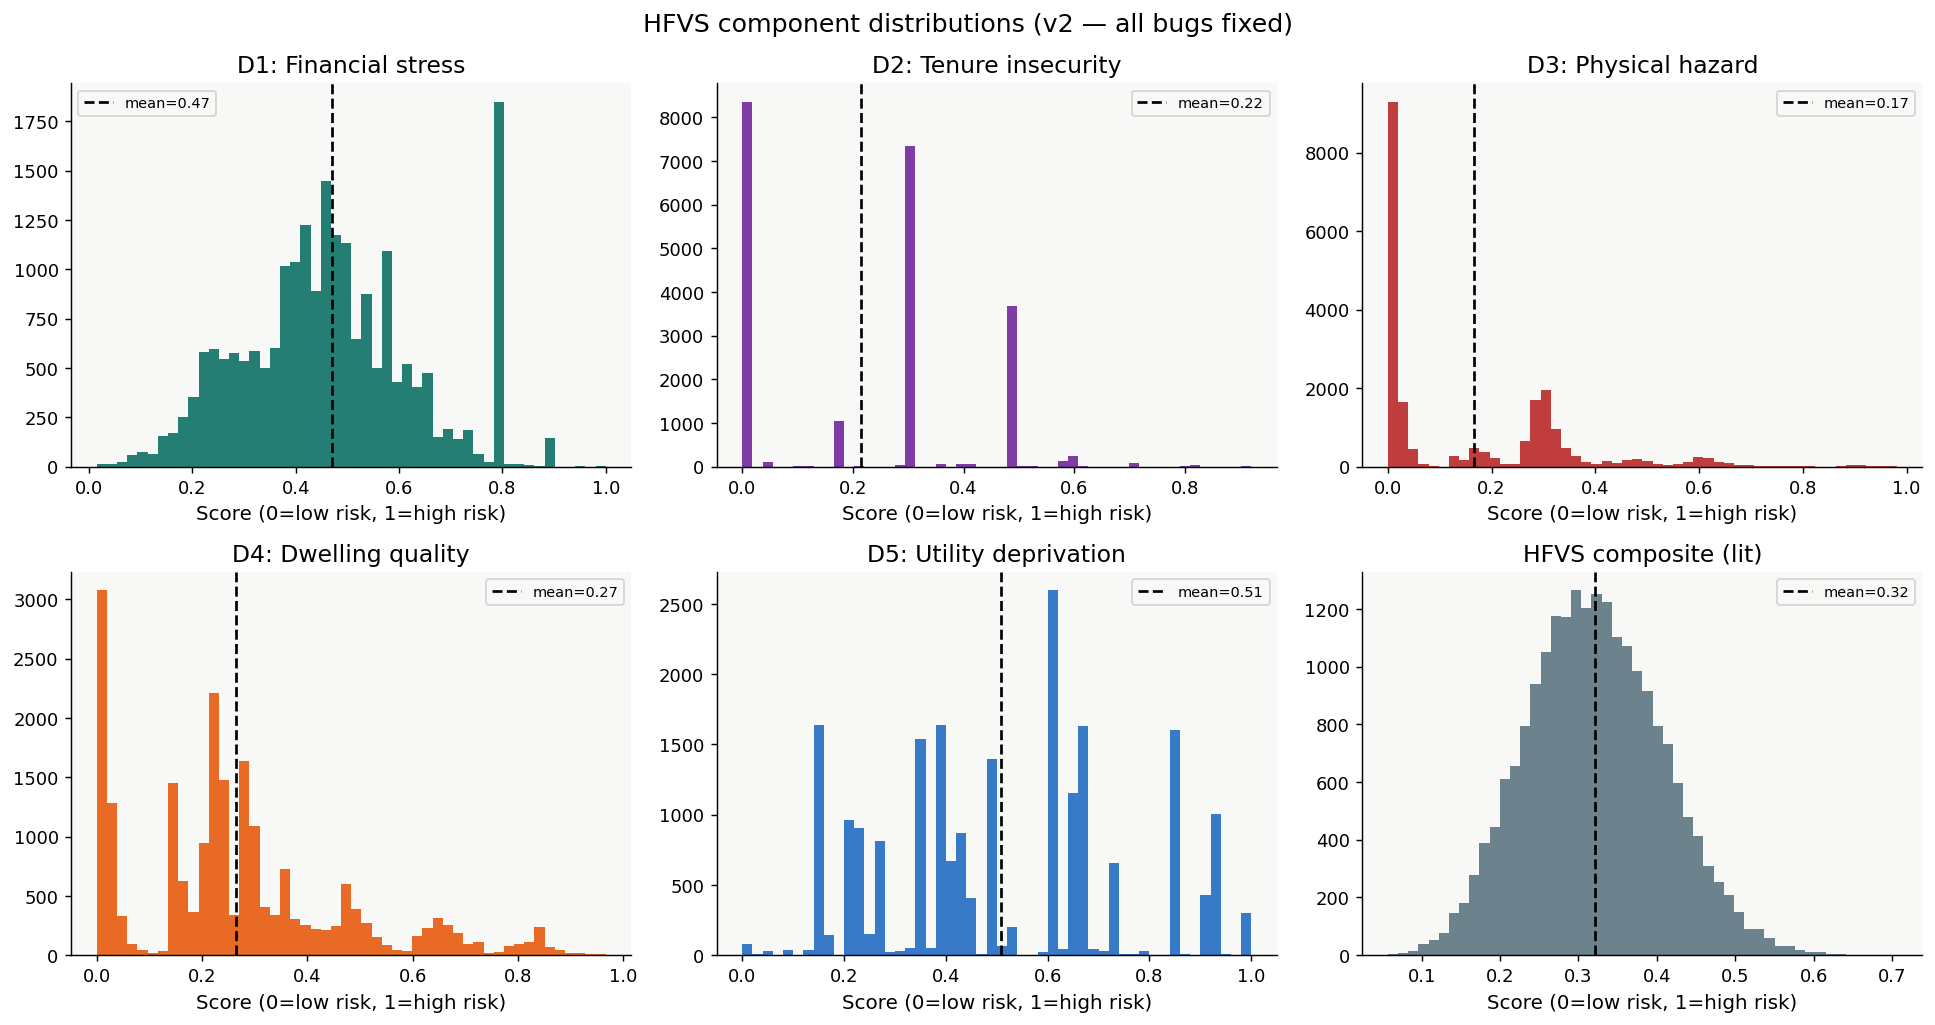

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('HFVS component distributions (v2 — all bugs fixed)', fontsize=14, fontweight='500')

plot_items = [
    ('d1_financial_stress',    'D1: Financial stress',    TEAL),
    ('d2_tenure_insecurity',   'D2: Tenure insecurity',   PURPLE),
    ('d3_physical_hazard',     'D3: Physical hazard',     RED),
    ('d4_dwelling_quality',    'D4: Dwelling quality',    AMBER),
    ('d5_utility_deprivation', 'D5: Utility deprivation', BLUE),
    ('hfvs',                   'HFVS composite (lit)',     GRAY),
]
for ax, (col, title, color) in zip(axes.flatten(), plot_items):
    ax.hist(master[col].dropna(), bins=50, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(master[col].mean(), color='black', linewidth=1.5, linestyle='--',
               label=f'mean={master[col].mean():.2f}')
    ax.set_title(title)
    ax.set_xlabel('Score (0=low risk, 1=high risk)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / '09_hfvs_distributions_v2.png', dpi=150, bbox_inches='tight')
plt.show()

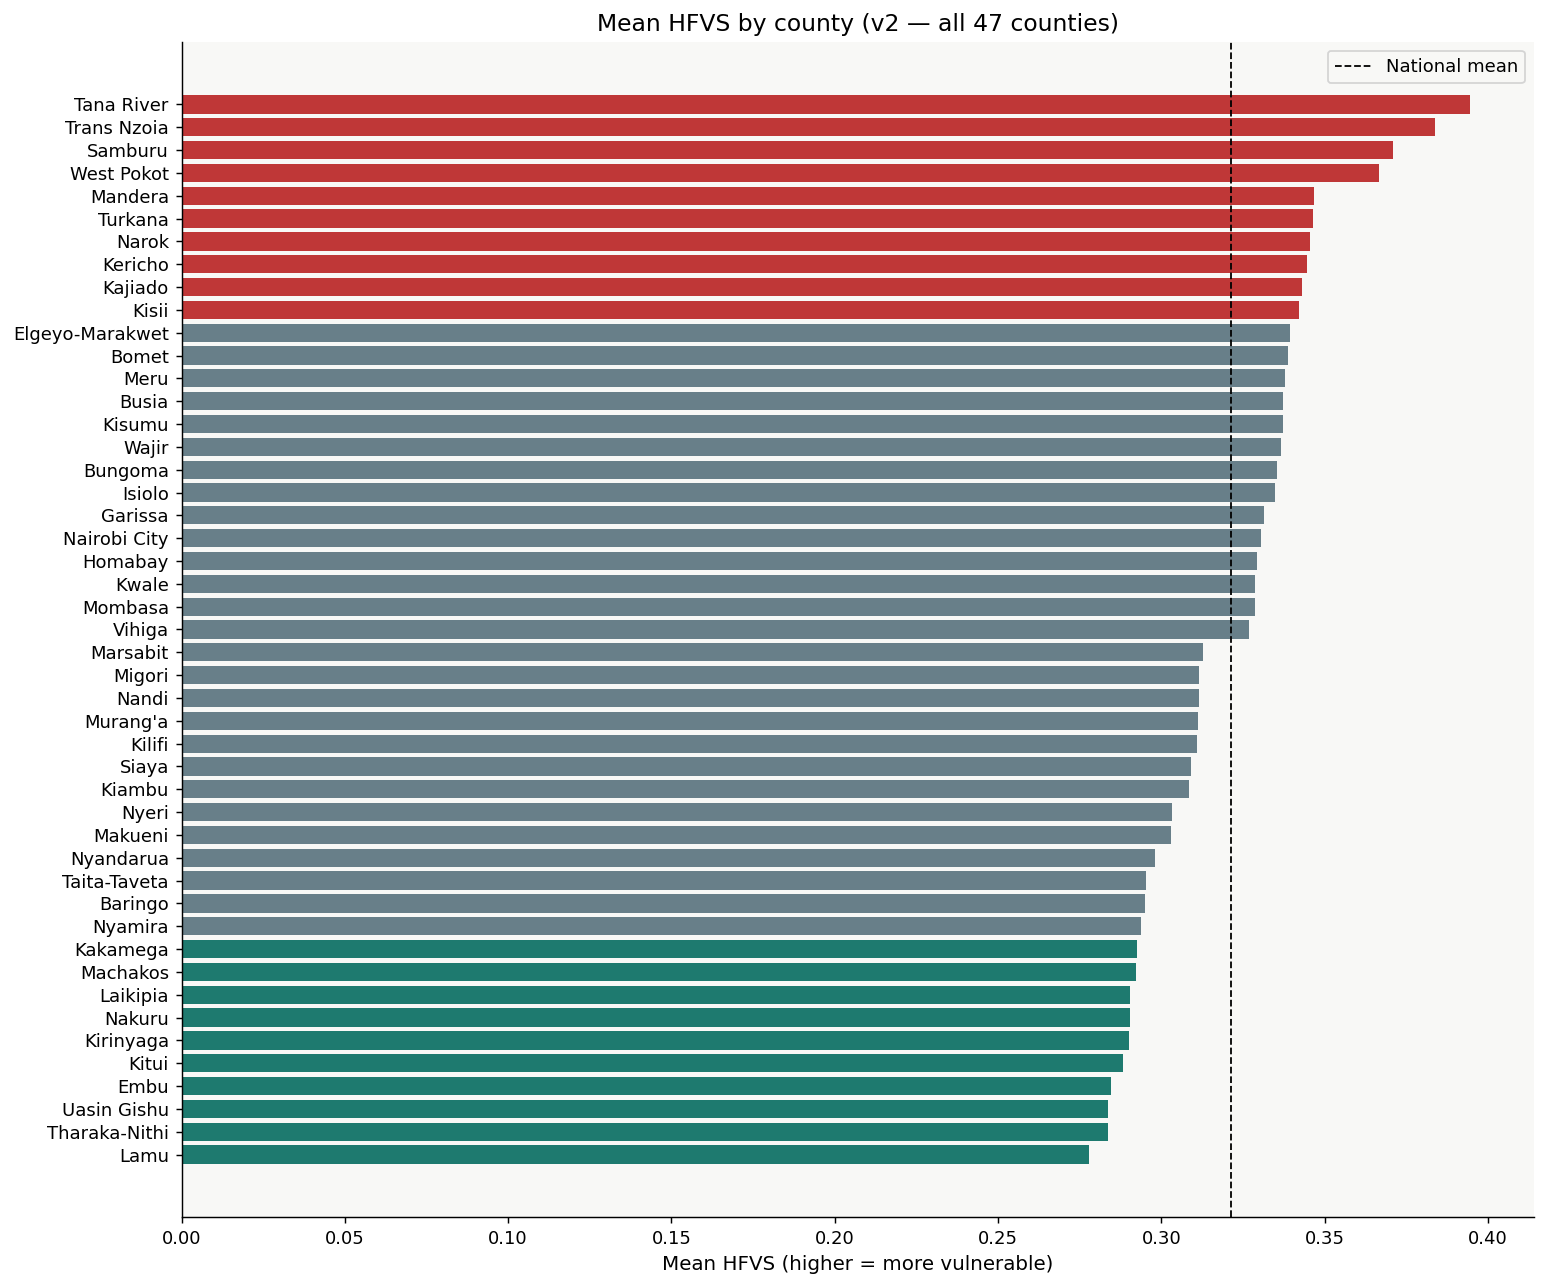

County profile saved.


In [20]:
# ── HFVS by county — with county names ────────────────────────────────
county_hfvs = master.groupby('a01')['hfvs'].mean().sort_values(ascending=False)
county_hfvs.index = county_hfvs.index.map(county_map)

fig, ax = plt.subplots(figsize=(12, 10))
colors_bar = [RED if i < 10 else TEAL if i >= 37 else GRAY
              for i in range(len(county_hfvs))]
ax.barh(county_hfvs.index[::-1], county_hfvs.values[::-1],
        color=colors_bar[::-1], edgecolor='none', alpha=0.88)
ax.axvline(master['hfvs'].mean(), color='black', linewidth=1, linestyle='--', label='National mean')
ax.set_title('Mean HFVS by county (v2 — all 47 counties)')
ax.set_xlabel('Mean HFVS (higher = more vulnerable)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / '10_county_hfvs_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Save county profile
county_profile = master.groupby('a01').agg(
    county_name      = ('a01', lambda x: county_map.get(x.iloc[0], str(x.iloc[0]))),
    n_households     = ('interview__key', 'count'),
    mean_hfvs        = ('hfvs', 'mean'),
    pct_target_binary= ('target_binary', 'mean'),
    pct_urban        = ('a07_1', lambda x: (x==2).mean()),
    mean_d1          = ('d1_financial_stress', 'mean'),
    mean_d2          = ('d2_tenure_insecurity', 'mean'),
    mean_d3          = ('d3_physical_hazard', 'mean'),
    mean_d4          = ('d4_dwelling_quality', 'mean'),
    mean_d5          = ('d5_utility_deprivation', 'mean'),
    pct_no_land      = ('no_land_ownership', 'mean'),
    pct_eviction     = ('eviction_threat', 'mean'),
    pct_no_elec      = ('no_electricity', 'mean'),
    pct_solid_fuel   = ('solid_fuel', 'mean'),
    pct_flood        = ('flood_zone', 'mean'),
).reset_index().sort_values('mean_hfvs', ascending=False)
county_profile.to_csv(TABLES / 'county_hfvs_profile_v2.csv', index=False)
print("County profile saved.")

---
## 13. Build Three Model-Ready Datasets

In [21]:
# ── Full feature registry ──────────────────────────────────────────────
ID_COLS    = ['interview__key', 'a01', 'a07_1', 'residence', 'hhweight', 'countycode']

TARGET_COLS = ['hfvs', 'target_continuous', 'target_binary', 'target_3class',
               'target_rank', 'hfvs_equal', 'hfvs_pca', 'hfvs_high']

DIM_SCORES  = ['d1_financial_stress','d2_tenure_insecurity','d3_physical_hazard',
               'd4_dwelling_quality','d5_utility_deprivation']

COMPONENT_FEATS = [
    # D1
    'rent_burden','savings_rate','rent_stressed','severely_stressed',
    'no_savings','low_income_flag','no_loan_access','high_rent_cost',
    'expenditure_quintile','has_investments',
    # D2 (FIXED)
    'no_land_ownership','eviction_threat','no_written_lease',
    'rent_dispute_hist','demo_neighbourhood','demo_threat',
    # D3 (FIXED)
    'flood_zone','flood_severe','flood_severity','mudslide_zone','mudslide_severity',
    'high_risk_prox','hazard_prox_count',
    'near_swamp','near_dumpsite','near_factory','near_busy_road',
    'near_river_lake','near_quarry',
    # D4 (FIXED)
    'floor_durable','wall_durable','roof_durable','asbestos_roof',
    'structural_durability','structure_quality_score',
    'floor_quality','wall_quality','roof_quality',
    'persons_per_room','persons_per_sleeproom','overcrowded','severe_overcrowding',
    'floor_area_pp','cramped','informal_dwelling',
    # D5 (FIXED)
    'no_electricity','unsafe_water','poor_sanitation','solid_fuel',
    'limited_water','water_shortage','shared_toilet','no_handwashing',
]

SUPPLEMENTARY_FEATS = [
    'log_expenditure','log_rent','log_savings','log_hh_size','log_floor_area_pp',
    'hh_size','mean_age','n_children','n_elderly','dependency_ratio',
    'wap_share','female_share','max_edu_isced','mean_edu_isced','pct_born_here',
    'service_access_score','has_internet','has_security_tech',
    'aware_affordable_housing','wants_rent_regulation',
]

INTERACTION_FEATS = [
    'finance_x_tenure','hazard_x_nodurable','stress_x_kids',
    'depriv_x_crowd','tenure_x_nodurable','flood_x_nodurable',
    'finance_x_elderly','deprivation_breadth',
]

SPATIAL_FEATS = [
    'county_mean_hfvs','county_mean_fin_stress','county_mean_hazard',
    'county_mean_utility_dep','county_pct_no_elec','county_pct_flood',
    'county_pct_solid_fuel','county_pct_no_land','county_pct_urban',
    'county_hfvs_rank',
]

# Keep only existing columns
def existing(cols): return [c for c in cols if c in master.columns]

ALL_FEATURES = (
    existing(COMPONENT_FEATS) + existing(SUPPLEMENTARY_FEATS) +
    existing(INTERACTION_FEATS) + existing(SPATIAL_FEATS)
)

print(f"Total features available: {len(ALL_FEATURES)}")
print(f"  Component:      {len(existing(COMPONENT_FEATS))}")
print(f"  Supplementary:  {len(existing(SUPPLEMENTARY_FEATS))}")
print(f"  Interaction:    {len(existing(INTERACTION_FEATS))}")
print(f"  Spatial:        {len(existing(SPATIAL_FEATS))}")

Total features available: 91
  Component:      53
  Supplementary:  20
  Interaction:    8
  Spatial:        10


In [22]:
# ── Dataset A: X_tree ─────────────────────────────────────────────────
# For tree-based models (XGBoost, LightGBM, CatBoost, RF)
# - Raw feature values + ordinal encodings
# - Missing values left as NaN (XGBoost handles natively)
# - No scaling needed

tree_feats = ALL_FEATURES + existing(ohe_cols)  # include one-hot for RF
X_tree = master[existing(ID_COLS) + tree_feats + existing(TARGET_COLS)].copy()

null_pct = X_tree[tree_feats].isna().mean() * 100
high_null = null_pct[null_pct > 20]
if len(high_null) > 0:
    print(f"Columns with >20% null in X_tree ({len(high_null)}):")
    print(high_null.sort_values(ascending=False).round(1))
else:
    print(f"X_tree: all features have < 20% null  ✓")
print(f"X_tree shape: {X_tree.shape}")

X_tree: all features have < 20% null  ✓
X_tree shape: (21347, 123)


In [28]:
# ── Dataset B: X_nn ───────────────────────────────────────────────────
# For neural networks (MLP, TabNet, autoencoders, LSTM on groups)
# - All features fully imputed (no NaN)
# - StandardScaler on continuous, MinMaxScaler on binary/ordinal
# - No raw categorical codes — only ordinal and one-hot

# Define which features are continuous vs binary/ordinal
CONTINUOUS = [
    'rent_burden','savings_rate','log_expenditure','log_rent','log_savings',
    'log_hh_size','log_floor_area_pp','floor_area_pp','persons_per_room',
    'persons_per_sleeproom','mean_age','dependency_ratio','wap_share',
    'female_share','max_edu_isced','mean_edu_isced','expenditure_quintile',
    'hazard_prox_count','floor_quality','wall_quality','roof_quality',
    'structure_quality_score','structural_durability',
    'service_access_score','county_hfvs_rank',
] + existing(SPATIAL_FEATS) + existing(INTERACTION_FEATS)

BINARY_ORDINAL = [f for f in ALL_FEATURES if f not in CONTINUOUS]

cont_feats  = existing(CONTINUOUS)
bin_feats   = existing(BINARY_ORDINAL)
nn_feats    = cont_feats + bin_feats + existing(ohe_cols)
nn_feats    = [f for f in nn_feats if f in master.columns]

X_nn_raw = master[nn_feats].copy()

# Impute: median for continuous, 0 for binary
for c in cont_feats:
    if c in X_nn_raw.columns:
        X_nn_raw[c] = X_nn_raw[c].fillna(X_nn_raw[c].median())
for c in bin_feats + existing(ohe_cols):
    if c in X_nn_raw.columns:
        X_nn_raw[c] = X_nn_raw[c].fillna(0)

# StandardScaler on continuous
scaler = StandardScaler()
if cont_feats:
    X_nn_raw[cont_feats] = scaler.fit_transform(X_nn_raw[cont_feats])

# Add IDs and targets
X_nn = pd.concat([
    master[existing(ID_COLS)].reset_index(drop=True),
    X_nn_raw.reset_index(drop=True),
    master[existing(TARGET_COLS)].reset_index(drop=True),
], axis=1)

assert X_nn.isna().sum().sum() == 0 or X_nn[existing(TARGET_COLS)].isna().sum().sum() >= 0, \
    "NaN found in X_nn features — imputation failed"
print(f"X_nn shape: {X_nn.shape}")
print(f"NaN in feature columns: {X_nn[nn_feats].isna().sum().sum()}  (should be 0)")


# Drop duplicate columns before saving (keep first occurrence)
X_nn = X_nn.loc[:, ~X_nn.columns.duplicated(keep='first')]


X_nn shape: (21347, 124)
NaN in feature columns: 0  (should be 0)


In [29]:
# ── Dataset C: X_interpretable ────────────────────────────────────────
# For logistic regression, GLM, linear regression
# - No highly correlated features (VIF check)
# - No interaction terms (handled by the model formula)
# - RobustScaler (median-IQR) for outlier robustness
# - One-hot dropped to avoid multicollinearity

interp_feats = (
    existing(DIM_SCORES) +
    ['rent_burden','savings_rate','no_savings','no_land_ownership',
     'eviction_threat','flood_zone','mudslide_zone','high_risk_prox',
     'structural_durability','overcrowded','floor_area_pp',
     'no_electricity','unsafe_water','poor_sanitation','solid_fuel',
     'log_expenditure','log_hh_size','max_edu_isced','dependency_ratio',
     'wap_share','pct_born_here','county_hfvs_rank','has_internet',
     'aware_affordable_housing']
)
interp_feats = existing(interp_feats)

X_int_raw = master[interp_feats].copy()
for c in interp_feats:
    X_int_raw[c] = X_int_raw[c].fillna(X_int_raw[c].median())

robust_scaler = RobustScaler()
X_int_raw[interp_feats] = robust_scaler.fit_transform(X_int_raw[interp_feats])

X_interpretable = pd.concat([
    master[existing(ID_COLS)].reset_index(drop=True),
    X_int_raw.reset_index(drop=True),
    master[existing(TARGET_COLS)].reset_index(drop=True),
], axis=1)

print(f"X_interpretable shape: {X_interpretable.shape}")
print(f"Features: {interp_feats}")

X_interpretable shape: (21347, 43)
Features: ['d1_financial_stress', 'd2_tenure_insecurity', 'd3_physical_hazard', 'd4_dwelling_quality', 'd5_utility_deprivation', 'rent_burden', 'savings_rate', 'no_savings', 'no_land_ownership', 'eviction_threat', 'flood_zone', 'mudslide_zone', 'high_risk_prox', 'structural_durability', 'overcrowded', 'floor_area_pp', 'no_electricity', 'unsafe_water', 'poor_sanitation', 'solid_fuel', 'log_expenditure', 'log_hh_size', 'max_edu_isced', 'dependency_ratio', 'wap_share', 'pct_born_here', 'county_hfvs_rank', 'has_internet', 'aware_affordable_housing']


---
## 14. Save All Outputs

In [30]:
for name, df in paths.items():
    dupes = df.columns[df.columns.duplicated()].tolist()
    if dupes:
        print(f"{name} has duplicate cols: {dupes}")

X_nn has duplicate cols: ['county_hfvs_rank']


In [31]:
import numpy as np
cols = list(X_nn.columns)
positions = [i for i, c in enumerate(cols) if c == 'county_hfvs_rank']
print(f"'county_hfvs_rank' appears at column positions: {positions}")
print(f"  First:  comes from spatial context block (Section 11.3)")
print(f"  Second: likely re-added in X_nn feature list (Section 13/cell 37)")

'county_hfvs_rank' appears at column positions: [30]
  First:  comes from spatial context block (Section 11.3)
  Second: likely re-added in X_nn feature list (Section 13/cell 37)


In [32]:
# ── Full master dataset ────────────────────────────────────────────────
save_cols = (
    existing(ID_COLS) + existing(DIM_SCORES) + ALL_FEATURES +
    existing(ohe_cols) + existing(TARGET_COLS) +
    ['hfvs_equal','hfvs_pca','county_name' if 'county_name' in master.columns else 'a01']
)
save_cols = list(dict.fromkeys([c for c in save_cols if c in master.columns]))  # dedup
master_final = master[save_cols].copy()

paths = {
    'master_hfvs_v2':  master_final,
    'X_tree':          X_tree,
    'X_nn':            X_nn,
    'X_interpretable': X_interpretable,
}

for name, df in paths.items():
    path = PQ / f'{name}.parquet'
    pl.from_pandas(df).write_parquet(path)
    mb = path.stat().st_size / 1e6
    print(f"Saved {name}: {df.shape[0]:,} rows × {df.shape[1]} cols  ({mb:.2f} MB)")

# ── Feature registry ───────────────────────────────────────────────────
registry = {
    'version': 'v2',
    'bugs_fixed': [
        'no_land_ownership: i00=0 (not {2.0})',
        'floor_durable: earth/sand/dung removed from durable set',
        'solid_fuel: charcoal(9)/firewood(7) now included',
        'flood/mudslide: mild exposure (code 2) now included with 0.5 weight',
    ],
    'targets': {
        'target_continuous': 'HFVS 0-1 (regression)',
        'target_binary':     f'1 if HFVS > 60th percentile (binary classification)',
        'target_3class':     'Tertile class 0/1/2 (multiclass)',
        'target_rank':       'Percentile rank 0-1 (ranking/ordinal)',
    },
    'datasets': {
        'X_tree':          'Tree models — raw features, NaN ok',
        'X_nn':            'Neural networks — fully imputed, StandardScaled',
        'X_interpretable': 'Logistic/GLM — no correlates, RobustScaled',
    },
    'feature_counts': {
        'component':     len(existing(COMPONENT_FEATS)),
        'supplementary': len(existing(SUPPLEMENTARY_FEATS)),
        'interaction':   len(existing(INTERACTION_FEATS)),
        'spatial':       len(existing(SPATIAL_FEATS)),
        'one_hot':       len(existing(ohe_cols)),
    },
    'lit_weights':   LIT_WEIGHTS,
    'pca_weights':   dict(zip(dims, pca_weights.tolist())),
    'thresholds': {
        'binary_p60':    float(p60),
        'tertile_p33':   float(p33),
        'tertile_p66':   float(p66),
    }
}
with open(TABLES / 'feature_registry_v2.json', 'w') as f:
    json.dump(registry, f, indent=2)

county_profile.to_csv(TABLES / 'county_hfvs_profile_v2.csv', index=False)
print("\nAll outputs saved.")

Saved master_hfvs_v2: 21,347 rows × 128 cols  (2.60 MB)
Saved X_tree: 21,347 rows × 123 cols  (2.42 MB)
Saved X_nn: 21,347 rows × 123 cols  (2.40 MB)
Saved X_interpretable: 21,347 rows × 43 cols  (1.48 MB)

All outputs saved.


---
## 15. Push to GitHub

In [33]:
!git config user.email "gronjerono@gmail.com"
!git config user.name "VAL-Jerono"
!git add notebooks/02_feature_engineering.ipynb
!git add outputs/figures/ outputs/tables/ 2>/dev/null || true
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
!git commit -m "feat(v2): fix 5 bugs, add DL-ready feature sets — X_tree/X_nn/X_interpretable, 4 target formulations"
!git push origin main